<a href="https://colab.research.google.com/github/tassegaetan1/colab-git-assignment2-UT/blob/main/FINAL_Project_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# Loan Default Prediction Project
# Comprehensive AI Application in Google Colab
# ============================================================

# =========================
# 1. Import Libraries
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


!pip install fairlearn

from fairlearn.metrics import MetricFrame, selection_rate, true_positive_rate, false_positive_rate
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

import warnings
warnings.filterwarnings("ignore")

In [3]:
# =========================
# 2. Upload and Load Dataset
# =========================
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('bank-loan.csv')
print("Dataset loaded successfully.")
df.head()

Saving bank-loan.csv to bank-loan (2).csv
Dataset loaded successfully.


,age,ed,employ,address,income,debtinc,creddebt,othdebt,default
0,41,3,17,12,176,9.3,11.359392,5.008608,1.0
1,27,1,10,6,31,17.3,1.362202,4.000798,0.0
2,40,1,15,14,55,5.5,0.856075,2.168925,0.0
3,41,1,15,14,120,2.9,2.658720,0.821280,0.0
4,24,2,2,0,28,17.3,1.787436,3.056564,1.0


In [4]:
# =========================
# 3. Explore the Dataset
# =========================
print("Shape of dataset:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nSummary statistics:")
display(df.describe())

Shape of dataset: (850, 9)

Columns:
Index(['age', 'ed', 'employ', 'address', 'income', 'debtinc', 'creddebt',
       'othdebt', 'default'],
      dtype='object')

Data types:
age           int64
ed            int64
employ        int64
address       int64
income        int64
debtinc     float64
creddebt    float64
othdebt     float64
default     float64
dtype: object

Missing values:
age           0
ed            0
employ        0
address       0
income        0
debtinc       0
creddebt      0
othdebt       0
default     150
dtype: int64

Summary statistics:


,age,ed,employ,address,income,debtinc,creddebt,othdebt,default
count,850.000000,850.000000,850.000000,850.000000,850.000000,850.000000,850.000000,850.000000,700.000000
mean,35.029412,1.710588,8.565882,8.371765,46.675294,10.171647,1.576805,3.078789,0.261429
std,8.041432,0.927784,6.777884,6.895016,38.543054,6.719441,2.125840,3.398803,0.439727
min,20.000000,1.000000,0.000000,0.000000,13.000000,0.100000,0.011696,0.045584,0.000000
25%,29.000000,1.000000,3.000000,3.000000,24.000000,5.100000,0.382176,1.045942,0.000000
50%,34.000000,1.000000,7.000000,7.000000,35.000000,8.700000,0.885091,2.003243,0.000000
75%,41.000000,2.000000,13.000000,12.000000,55.750000,13.800000,1.898440,3.903001,1.000000
max,56.000000,5.000000,33.000000,34.000000,446.000000,41.300000,20.561310,35.197500,1.000000


In [5]:
# =========================
# 4. Data Cleaning
# =========================
# Remove rows where the target is missing
df = df.dropna(subset=['default'])

# Fill missing numeric values with median
df = df.fillna(df.median(numeric_only=True))

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
age         0
ed          0
employ      0
address     0
income      0
debtinc     0
creddebt    0
othdebt     0
default     0
dtype: int64


In [6]:
# =========================
# 5. Feature Engineering
# =========================
# Total debt
df['total_debt'] = df['creddebt'] + df['othdebt']

# Income per year employed
df['income_per_year_employed'] = df['income'] / (df['employ'] + 1)

# Residential stability
df['residential_stability'] = df['address'] / (df['age'] + 1)

# Age group for fairness analysis
df['age_group'] = np.where(df['age'] > 40, 'Older', 'Younger')

df.head()

,age,ed,employ,address,income,debtinc,creddebt,othdebt,default,total_debt,income_per_year_employed,residential_stability,age_group
0,41,3,17,12,176,9.3,11.359392,5.008608,1.0,16.368,9.777778,0.285714,Older
1,27,1,10,6,31,17.3,1.362202,4.000798,0.0,5.363,2.818182,0.214286,Younger
2,40,1,15,14,55,5.5,0.856075,2.168925,0.0,3.025,3.437500,0.341463,Younger
3,41,1,15,14,120,2.9,2.658720,0.821280,0.0,3.480,7.500000,0.333333,Older
4,24,2,2,0,28,17.3,1.787436,3.056564,1.0,4.844,9.333333,0.000000,Younger


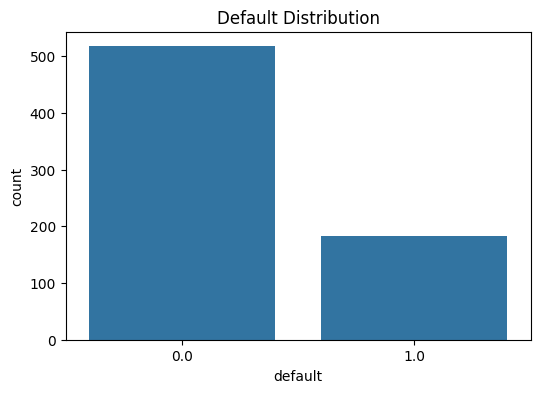

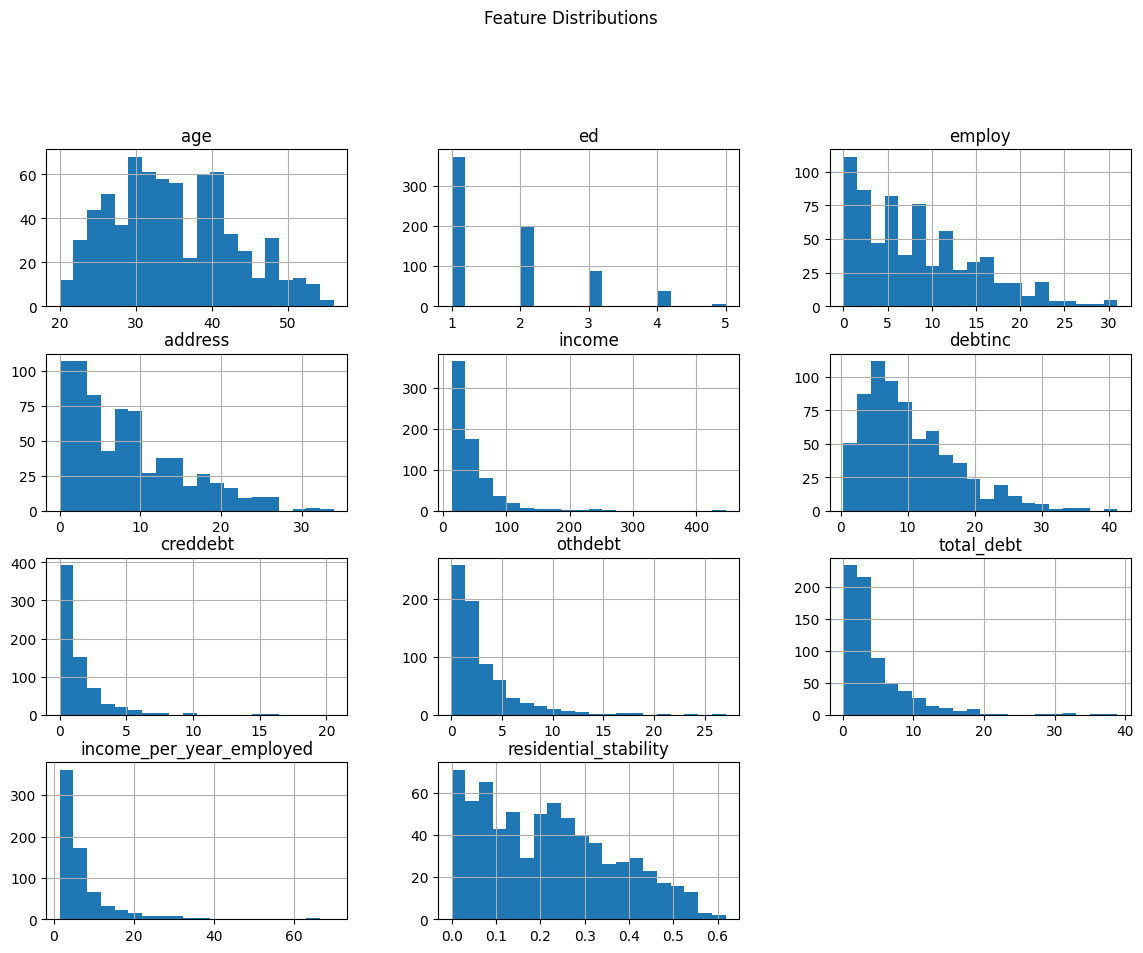

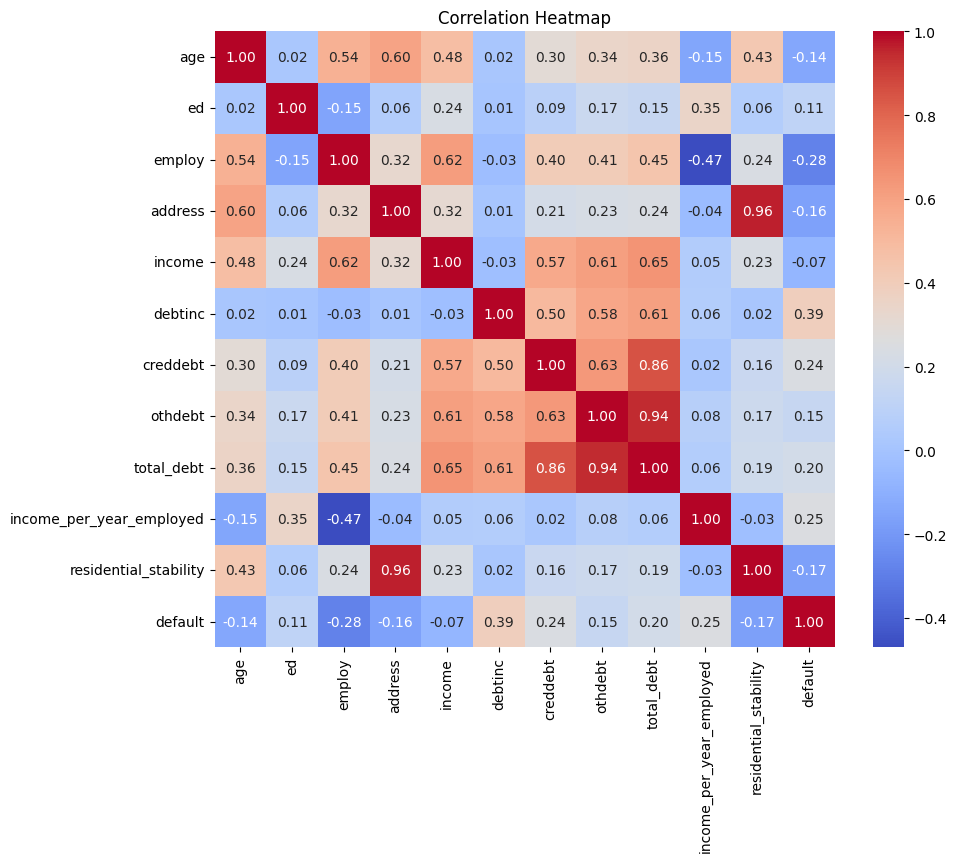

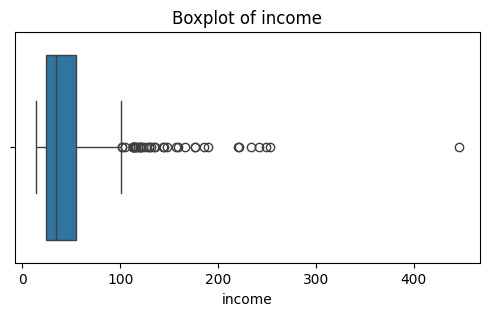

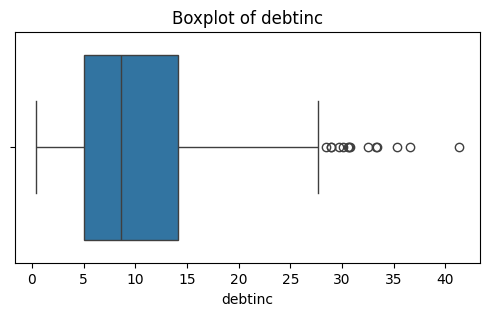

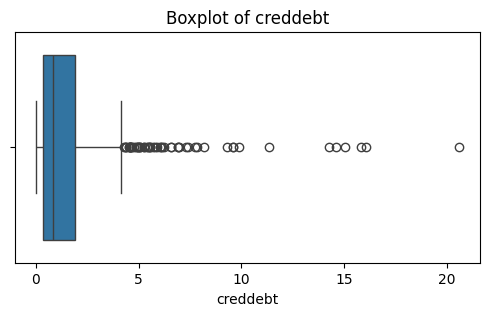

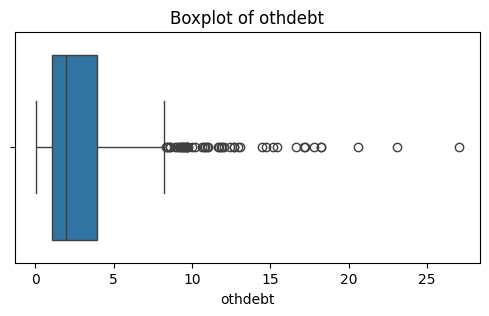

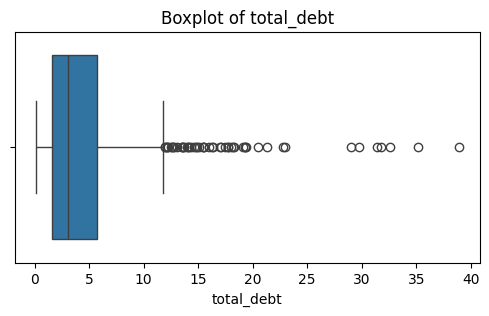

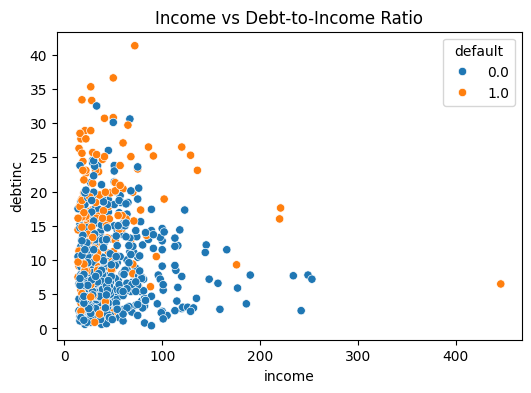

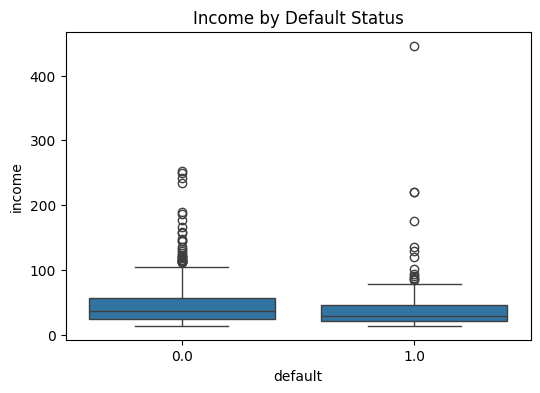

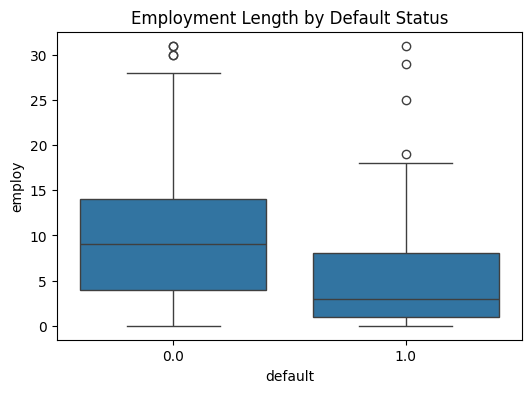

In [7]:
# =========================
# 6. Exploratory Data Analysis
# =========================
plt.figure(figsize=(6,4))
sns.countplot(x='default', data=df)
plt.title('Default Distribution')
plt.show()

numeric_cols = ['age', 'ed', 'employ', 'address', 'income', 'debtinc', 'creddebt', 'othdebt',
                'total_debt', 'income_per_year_employed', 'residential_stability']

df[numeric_cols].hist(figsize=(14,10), bins=20)
plt.suptitle('Feature Distributions', y=1.02)
plt.show()

# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols + ['default']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

# Boxplots to inspect outliers
for col in ['income', 'debtinc', 'creddebt', 'othdebt', 'total_debt']:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

# Relationship plots
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='income', y='debtinc', hue='default')
plt.title('Income vs Debt-to-Income Ratio')
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='default', y='income')
plt.title('Income by Default Status')
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='default', y='employ')
plt.title('Employment Length by Default Status')
plt.show()

In [8]:
# =========================
# 7. Prepare Features and Target
# =========================
X = df.drop(columns=['default', 'age_group'])
y = df['default']

# Since the dataset is numeric, no encoding is required here.
# If your dataset had categorical columns, use pd.get_dummies().

feature_names = X.columns
print("Features:")
print(feature_names)

Features:
Index(['age', 'ed', 'employ', 'address', 'income', 'debtinc', 'creddebt',
       'othdebt', 'total_debt', 'income_per_year_employed',
       'residential_stability'],
      dtype='object')


In [9]:
# =========================
# 8. Scale Features
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=feature_names)
X_scaled.head()

,age,ed,employ,address,income,debtinc,creddebt,othdebt,total_debt,income_per_year_employed,residential_stability
0,0.768304,1.376911,1.294313,0.545664,3.544603,-0.140798,4.634831,0.593692,2.396269,0.333762,0.458181
1,-0.983529,-0.779325,0.242201,-0.334101,-0.396908,1.031818,-0.090444,0.286919,0.153125,-0.609902,-0.013724
2,0.643173,-0.779325,0.993709,0.838919,0.255480,-0.697790,-0.329670,-0.270693,-0.323429,-0.525927,0.826498
3,0.768304,-0.779325,0.993709,0.838919,2.022364,-1.078890,0.522369,-0.680910,-0.230686,0.024914,0.772785
4,-1.358922,0.298793,-0.960214,-1.213867,-0.478457,1.031818,0.110547,-0.000501,0.047337,0.273499,-1.429439


In [10]:
# =========================
# 9. Train-Test Split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (560, 11)
Testing set shape: (140, 11)


In [11]:
# =========================
# 10. Baseline Model
# =========================
rf = RandomForestClassifier(random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 3))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.779
ROC-AUC: 0.796

Confusion Matrix:
[[93 10]
 [21 16]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.82      0.90      0.86       103
         1.0       0.62      0.43      0.51        37

    accuracy                           0.78       140
   macro avg       0.72      0.67      0.68       140
weighted avg       0.76      0.78      0.76       140



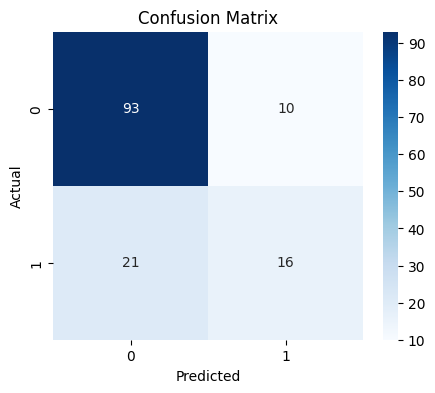

In [12]:
# =========================
# 11. Confusion Matrix Plot
# =========================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

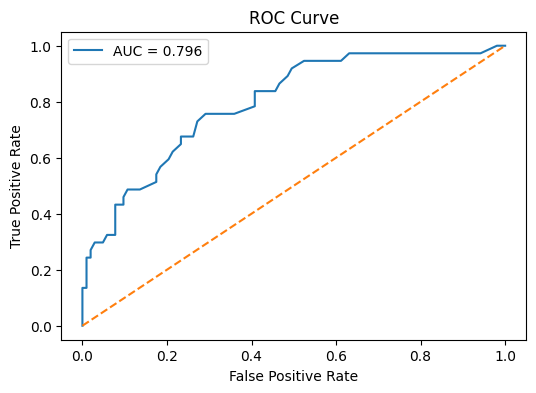

In [13]:
# =========================
# 12. ROC Curve
# =========================
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [14]:
# =========================
# 13. Hyperparameter Tuning
# =========================
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6, 8, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 3, 5]
}

grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Cross-Validation ROC-AUC:", round(grid.best_score_, 3))

Best Parameters: {'max_depth': 8, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 100}
Best Cross-Validation ROC-AUC: 0.815


In [15]:
# =========================
# 15. Cross-Validation
# =========================

best_model = grid.best_estimator_
try:
    best_model
except:
    best_model = model

cv_scores = cross_val_score(best_model, X_scaled, y, cv=5, scoring='roc_auc')

print("Cross-validation ROC-AUC scores:", cv_scores)
print("Mean CV ROC-AUC:", round(cv_scores.mean(), 3))

Cross-validation ROC-AUC scores: [0.78876935 0.75229599 0.86329047 0.84268162 0.8034188 ]
Mean CV ROC-AUC: 0.81


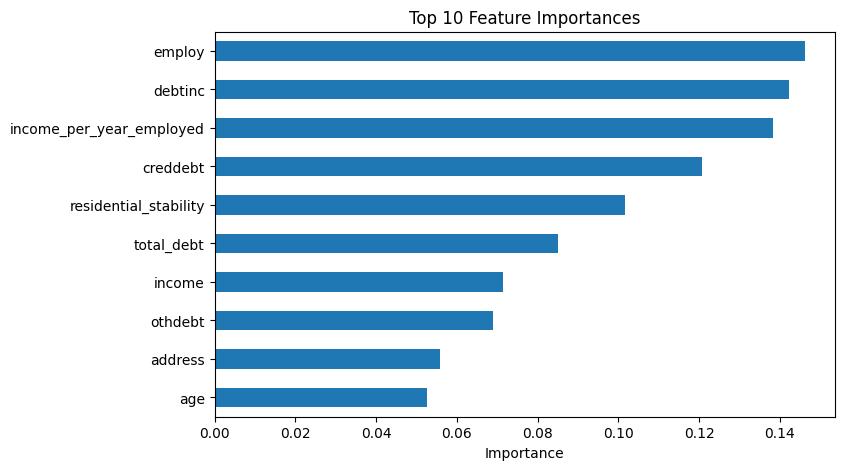

Top important features:
employ                      0.146267
debtinc                     0.142388
income_per_year_employed    0.138250
creddebt                    0.120844
residential_stability       0.101745
total_debt                  0.085076
income                      0.071511
othdebt                     0.068892
address                     0.055891
age                         0.052714
dtype: float64


In [16]:
# =========================
# 16. Feature Importance
# =========================
importances = best_model.feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(8,5))
feat_imp.head(10).plot(kind='barh')
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.show()

print("Top important features:")
print(feat_imp.head(10))

,Count,Selection Rate,TPR,FPR,Accuracy
age_group,,,,,
Older,33,0.151515,0.375000,0.080000,0.787879
Younger,107,0.196262,0.448276,0.102564,0.775701


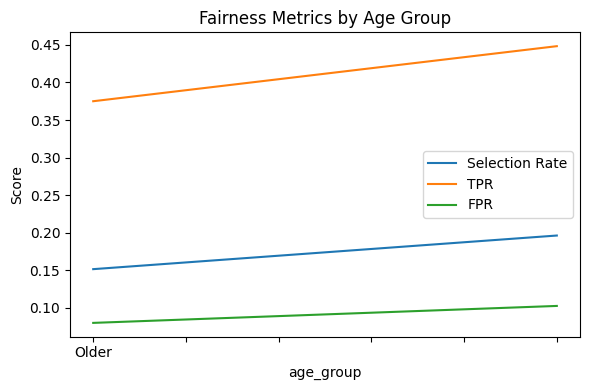

In [19]:
# =========================
# 17. Fairness Analysis by Age Group
# =========================


# =========================
# Ensure prediction exists
# =========================
y_pred_best = rf.predict(X_test)

# =========================
# Align indexes
# =========================
y_test = y_test.reset_index(drop=True)
y_pred_best = pd.Series(y_pred_best).reset_index(drop=True)

# =========================
# Split sensitive feature
# =========================
_, sensitive_test = train_test_split(
    df['age_group'],
    test_size=0.2,
    random_state=42,
    stratify=y
)

sensitive_test = sensitive_test.reset_index(drop=True)
# Define fairness metrics
metrics = {
    "Selection Rate": selection_rate,
    "TPR": true_positive_rate,
    "FPR": false_positive_rate
}

# Compute fairness metrics
fairness_frame = MetricFrame(
    metrics=metrics,
    y_true=y_test,
    y_pred=y_pred_best,
    sensitive_features=sensitive_test
)

# Convert to DataFrame
fairness_df = fairness_frame.by_group.copy()

# Add group counts (FIX alignment)
counts = sensitive_test.value_counts().reindex(fairness_df.index)
fairness_df['Count'] = counts

# Compute accuracy per group (FIX indexing)
group_accuracy = {}
for g in fairness_df.index:
    idx = (sensitive_test == g)
    group_accuracy[g] = accuracy_score(y_test[idx], y_pred_best[idx])

fairness_df['Accuracy'] = pd.Series(group_accuracy)

# Reorder columns
fairness_df = fairness_df[['Count', 'Selection Rate', 'TPR', 'FPR', 'Accuracy']]

# Display results
display(fairness_df)

# =========================
# Plot
# =========================
fairness_df[['Selection Rate', 'TPR', 'FPR']].plot(figsize=(6, 4))
plt.title("Fairness Metrics by Age Group")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

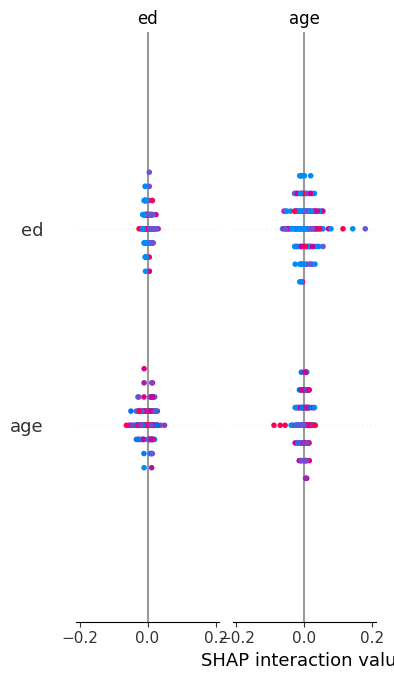

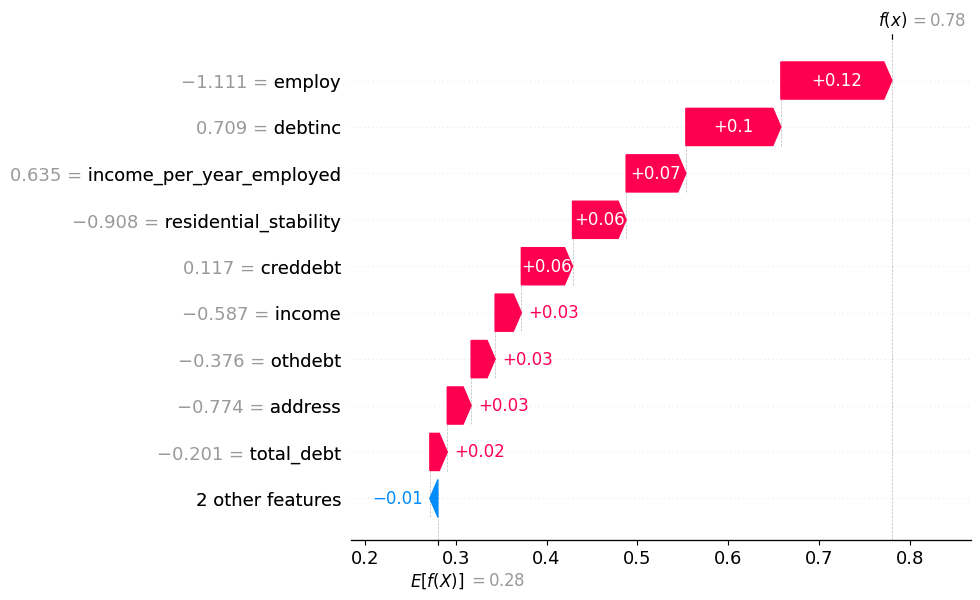

In [23]:
# =========================
# 18. SHAP Explainability
# =========================

import shap

# Use your trained model (rf)
explainer = shap.Explainer(rf, X_train)

# Disable additivity check (important fix)
shap_values = explainer(X_test, check_additivity=False)

# =========================
# Global explanation
# =========================
shap.summary_plot(shap_values, X_test, plot_type='bar')

# =========================
# Local explanation
# =========================
shap.plots.waterfall(shap_values[0, :, 1])

In [24]:
# =========================
# 19. Interactive Colab Deployment
# =========================
import ipywidgets as widgets
from IPython.display import display

age_widget = widgets.FloatText(value=35, description='Age')
ed_widget = widgets.FloatText(value=2, description='Education')
employ_widget = widgets.FloatText(value=5, description='Employ')
address_widget = widgets.FloatText(value=7, description='Address')
income_widget = widgets.FloatText(value=45, description='Income')
debtinc_widget = widgets.FloatText(value=18, description='DebtInc')
creddebt_widget = widgets.FloatText(value=2.5, description='CredDebt')
othdebt_widget = widgets.FloatText(value=3.0, description='OthDebt')

button = widgets.Button(description="Predict Default Risk")
output = widgets.Output()

def predict_default(b):
    with output:
        output.clear_output()

        total_debt = creddebt_widget.value + othdebt_widget.value
        income_per_year_employed = income_widget.value / (employ_widget.value + 1)
        residential_stability = address_widget.value / (age_widget.value + 1)

        new_data = pd.DataFrame({
            'age': [age_widget.value],
            'ed': [ed_widget.value],
            'employ': [employ_widget.value],
            'address': [address_widget.value],
            'income': [income_widget.value],
            'debtinc': [debtinc_widget.value],
            'creddebt': [creddebt_widget.value],
            'othdebt': [othdebt_widget.value],
            'total_debt': [total_debt],
            'income_per_year_employed': [income_per_year_employed],
            'residential_stability': [residential_stability]
        })

        new_scaled = scaler.transform(new_data)
        pred = best_model.predict(new_scaled)[0]
        prob = best_model.predict_proba(new_scaled)[0][1]

        if pred == 1:
            print(f"Prediction: HIGH RISK of default")
        else:
            print(f"Prediction: LOW RISK of default")
        print(f"Probability of default: {prob:.3f}")

button.on_click(predict_default)

display(age_widget, ed_widget, employ_widget, address_widget,
        income_widget, debtinc_widget, creddebt_widget, othdebt_widget,
        button, output)

FloatText(value=35.0, description='Age')

FloatText(value=2.0, description='Education')

FloatText(value=5.0, description='Employ')

FloatText(value=7.0, description='Address')

FloatText(value=45.0, description='Income')

FloatText(value=18.0, description='DebtInc')

FloatText(value=2.5, description='CredDebt')

FloatText(value=3.0, description='OthDebt')

Button(description='Predict Default Risk', style=ButtonStyle())

Output()